# 09 — Independent Complex Validation with Boltz-2

**Purpose:** Validate all 31 PD-L1 mini-binder designs using Boltz-2, an independent deep-learning structure prediction model, to assess whether binder–target complexes predicted by RFdiffusion are recapitulated from sequence alone.

**Scientific question:** For each designed binder sequence, does an independent structure prediction model — given *only* the binder and PD-L1 sequences with no structural hints — predict a plausible protein–protein complex? If yes, this provides orthogonal evidence that the binding interface is encoded in the designed sequence, not just in the RFdiffusion-designed pose.

**Key distinction from ESMFold (Notebook 05):** ESMFold validated single-chain fold recapitulation — the binder folds into the intended backbone shape in isolation. Boltz-2 validates multi-chain complex formation — the binder and PD-L1 form a plausible interface together. This is a stronger test because a sequence can fold correctly on its own but fail to dock onto its target.

**What Boltz-2 is:** An open-source deep-learning model (MIT, Wohlwend et al. 2024–2025) that predicts the 3D structure of biomolecular complexes from sequence, achieving AlphaFold 3-level accuracy. It produces confidence metrics — ipTM, complex pLDDT, complex PDE — that have been shown to correlate with experimental binding success better than physics-based scores.

**What Boltz-2 is NOT used for here:** Boltz-2 also includes a binding affinity prediction module, but this was trained on protein–small molecule data, not protein–protein interactions. We extract only the structure confidence metrics, which are valid for protein–protein complexes.

**Inputs:**
- 31 binder sequences from ProteinMPNN (via the parameter sensitivity manifests)
- PD-L1 ectodomain sequence (115 residues, from 4ZQK chain A)
- RFdiffusion designed-pose PDBs (for structural comparison)

**Outputs:**
- `09_boltz_confidence_scores.csv` — ipTM, complex_pLDDT, complex_pde, pTM for all 31 designs
- `09_boltz_vs_fingerprinting.csv` — correlation of Boltz metrics with NB07 fingerprinting features
- `09_boltz_tier_classification.csv` — designs classified as validated / uncertain / failed
- `09_boltz_summary.json` — structured summary for portfolio page
- Boltz-predicted complex CIF files for downstream analysis

**Compute:** Boltz-2 on Colab T4 GPU. Each complex (~185 residues) takes ~2–5 min. Total: ~1–2.5 hours for 31 designs.


In [1]:
# ============================================================
# Cell 0 — Colab setup: install dependencies, restart once, require GPU
# ============================================================
#
# Dependencies: None (first cell)
# External files: None
# Compute: CPU for install; GPU required for prediction later
# Purpose:
#   1. Install a Boltz-compatible scientific Python stack.
#   2. Force a one-time runtime restart after dependency changes.
#   3. Verify pandas/numpy/torch/boltz imports after restart.
#
# Why the restart matters:
#   Colab often preloads numpy/matplotlib before this cell runs. If pip then
#   changes numpy underneath the live kernel, pandas/scipy can fail with:
#       ValueError: numpy.dtype size changed...
#   A clean restart after install is the reliable fix.
# ============================================================

import os
import sys
import shutil
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
SETUP_SENTINEL = Path("/content/.boltz_colab_setup_complete") if IN_COLAB else Path(".boltz_colab_setup_complete")

print(f"Running in Colab: {IN_COLAB}")
print(f"Python: {sys.version.split()[0]}")

# Boltz 2.x declares numpy>=1.26,<2.0 and pandas>=2.2.2.
# Pinning numpy<2 avoids Colab's numpy-2 / compiled-extension mismatch.
packages = [
    "numpy==1.26.4",
    "pandas==2.2.2",
    "scipy==1.13.1",
    "matplotlib==3.8.4",
    "pyyaml>=6.0.1",
    "biopython>=1.83",
    "boltz[cuda]",
]

if not SETUP_SENTINEL.exists():
    print("Installing/updating required packages...")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-U", "--no-cache-dir", *packages
    ])

    # Smoke test in a separate fresh Python process. This catches resolver failures
    # without relying on the current, possibly contaminated notebook kernel.
    print("\nSmoke-testing imports in a fresh Python process...")
    subprocess.check_call([
        sys.executable, "-c",
        "import numpy, pandas, scipy, yaml, Bio; "
        "print('numpy', numpy.__version__); "
        "print('pandas', pandas.__version__); "
        "print('scipy', scipy.__version__)"
    ])

    SETUP_SENTINEL.write_text("ok\n")

    if IN_COLAB:
        print("\nPackages installed. Restarting the Colab runtime once to clear binary state...")
        try:
            from google.colab import runtime
            runtime.restart_runtime()
        except Exception:
            os.kill(os.getpid(), 9)
    else:
        print("\nPackages installed. Restart this kernel once, then rerun Cell 0.")
        raise SystemExit("Restart kernel, then rerun Cell 0.")

# After restart/rerun, imports happen against a clean kernel.
print("Dependency sentinel found. Verifying runtime imports...")
import numpy as np
import pandas as pd
import scipy
import yaml
import Bio
import torch

print(f"numpy:  {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"scipy:  {scipy.__version__}")
print(f"torch:  {torch.__version__}")

if not torch.cuda.is_available():
    raise RuntimeError(
        "No CUDA GPU detected. In Colab, use Runtime → Change runtime type → GPU. "
        "Do not run Boltz on CPU for this notebook."
    )
print(f"GPU: {torch.cuda.get_device_name(0)}")

boltz_exe = shutil.which("boltz")
if boltz_exe is None:
    raise RuntimeError("Boltz command-line executable was not found after installation.")
print(f"Boltz executable: {boltz_exe}")

print("\n✓ Setup complete")


Running in Colab: True
Python: 3.12.13
Dependency sentinel found. Verifying runtime imports...
numpy:  1.26.4
pandas: 2.2.2
scipy:  1.13.1
torch:  2.11.0+cu128
GPU: Tesla T4
Boltz executable: /usr/local/bin/boltz

✓ Setup complete


In [2]:
# ============================================================
# Cell 1 — Mount Drive, set paths, preflight files, load manifest
# ============================================================
#
# Dependencies: Cell 0 (installed packages)
# External files:
#   Preferred:
#     - final_ranked_candidates.csv, ranked_candidates_all_conditions.csv, or validation CSV anywhere under data/results/
#   Fallback:
#     - one or more esmfold_binder_predictions.csv files anywhere under the project
#   Required:
#     - PD-L1 structure file in data/structures/
#       Preferred: pdl1_clean.pdb
#       Also accepted: 4ZQK.pdb, pdb4zqk.ent, 4zqk.cif, 4ZQK.cif
#
# This cell is intentionally path-tolerant for Colab/Drive sync weirdness.
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import yaml
import warnings
warnings.filterwarnings('ignore')

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print(f"Drive mount skipped or unavailable: {e}")

# --- Project paths ---
PROJECT_DIR_CANDIDATES = [
    Path("/content/drive/Othercomputers/My Mac/pdl1-mini-binder-design"),
    Path("/content/drive/MyDrive/pdl1-mini-binder-design"),
    Path("/content/pdl1-mini-binder-design"),
]

def find_project_dir():
    """Find the project root regardless of how Drive exposes the synced Mac folder."""
    for p in PROJECT_DIR_CANDIDATES:
        if (p / "data").exists():
            return p
    for root in [Path("/content/drive"), Path("/content")]:
        if root.exists():
            for hit in root.glob("**/pdl1-mini-binder-design"):
                if (hit / "data").exists():
                    return hit
    return PROJECT_DIR_CANDIDATES[0]

DRIVE_BASE = find_project_dir()
print(f"Project directory: {DRIVE_BASE}")

DATA_DIR = DRIVE_BASE / "data"
RESULTS_DIR = DATA_DIR / "results"
STRUCTURE_DIR_CANDIDATES = [
    DATA_DIR / "structures",
    RESULTS_DIR / "structures",
    DRIVE_BASE / "structures",
]

STRUCTURE_DIR = next((p for p in STRUCTURE_DIR_CANDIDATES if p.exists()), STRUCTURE_DIR_CANDIDATES[0])
BOLTZ_DIR = RESULTS_DIR / "boltz_complex_validation"
BOLTZ_DIR.mkdir(parents=True, exist_ok=True)

# --- Locate PD-L1 structure ---
PDL1_STRUCTURE_NAMES = [
    "pdl1_clean.pdb",
    "4ZQK.pdb",
    "4zqk.pdb",
    "pdb4zqk.ent",
    "4ZQK.ent",
    "4zqk.ent",
    "4zqk.cif",
    "4ZQK.cif",
]

PDL1_STRUCTURE_CANDIDATES = []
for sdir in STRUCTURE_DIR_CANDIDATES:
    for name in PDL1_STRUCTURE_NAMES:
        PDL1_STRUCTURE_CANDIDATES.append(sdir / name)

NATIVE_STRUCTURE = next((p for p in PDL1_STRUCTURE_CANDIDATES if p.exists()), None)

# Last-resort recursive search for the cleaned/native structure.
if NATIVE_STRUCTURE is None and DRIVE_BASE.exists():
    for name in PDL1_STRUCTURE_NAMES:
        hits = list(DRIVE_BASE.glob(f"**/{name}"))
        if hits:
            NATIVE_STRUCTURE = hits[0]
            STRUCTURE_DIR = NATIVE_STRUCTURE.parent
            break

# --- Locate study/manifests robustly ---
MANIFEST_PRIORITY = [
    # Actual names produced by the param sensitivity notebook
    "final_ranked_candidates.csv",              # preferred: final filtered + ranked set
    "ranked_candidates_all_conditions.csv",     # broader ranked table
    "all_conditions_validation_results.csv",    # validation table across all conditions
    "condition_summary_enriched.csv",
    "condition_summary.csv",

    # Older/alternate names
    "ranked_candidates.csv",
    "validation_results.csv",
    "final_candidates.csv",
    "final_pass_candidates.csv",
    "validated_candidates.csv",
]

def find_manifest_csv():
    """Prefer ranked/validation manifests anywhere under data/results, then project-wide."""
    search_roots = [RESULTS_DIR, DATA_DIR, DRIVE_BASE]
    for root in search_roots:
        if not root.exists():
            continue
        for name in MANIFEST_PRIORITY:
            hits = sorted(root.glob(f"**/{name}"))
            if hits:
                return hits[0]
    return None

MANIFEST_CSV = find_manifest_csv()
STUDY_DIR = MANIFEST_CSV.parent if MANIFEST_CSV else (RESULTS_DIR / "param_sensitivity")

# --- Preflight: structure required; manifest preferred but not strictly required ---
missing = []
if not DRIVE_BASE.exists():
    missing.append(str(DRIVE_BASE))
if not DATA_DIR.exists():
    missing.append(str(DATA_DIR))
if not RESULTS_DIR.exists():
    missing.append(str(RESULTS_DIR))
if NATIVE_STRUCTURE is None:
    missing.append("one of: " + " OR ".join(str(p) for p in PDL1_STRUCTURE_CANDIDATES))

if missing:
    print("Missing required inputs:")
    for m in missing:
        print(f"  - {m}")

    print("\nFiles visible near data/results:")
    for d in [DATA_DIR, RESULTS_DIR, STRUCTURE_DIR]:
        if d.exists():
            print(f"\n{d}:")
            for p in sorted(d.iterdir())[:50]:
                print(f"  - {p.name}")
    raise FileNotFoundError("Preflight failed. Fix project paths or copy required files into Drive.")

print("✓ Preflight passed")
print(f"Using PD-L1 structure: {NATIVE_STRUCTURE}")
print(f"Using structure directory: {STRUCTURE_DIR}")
print(f"Manifest CSV: {MANIFEST_CSV if MANIFEST_CSV else 'not found; will reconstruct from ESMFold prediction CSVs'}")
print(f"Study directory: {STUDY_DIR}")

# --- Extract PD-L1 sequence from structure ---
from Bio.PDB import PDBParser, MMCIFParser
from Bio.PDB.Polypeptide import is_aa
from Bio.Data.IUPACData import protein_letters_3to1

if NATIVE_STRUCTURE.suffix.lower() == ".cif":
    parser = MMCIFParser(QUIET=True)
else:
    parser = PDBParser(QUIET=True)

structure = parser.get_structure("PDL1", str(NATIVE_STRUCTURE))
model = structure[0]

def chain_sequence(chain):
    residues = [
        r for r in chain.get_residues()
        if r.id[0] == ' ' and is_aa(r, standard=True)
    ]
    seq = ''.join(
        protein_letters_3to1.get(r.get_resname().capitalize(), 'X')
        for r in residues
    )
    return seq

chain_seqs = {chain.id: chain_sequence(chain) for chain in model}
chain_seqs = {cid: seq for cid, seq in chain_seqs.items() if len(seq) > 0}

if not chain_seqs:
    raise RuntimeError(f"No protein chains found in {NATIVE_STRUCTURE}")

if "A" in chain_seqs and len(chain_seqs["A"]) >= 50:
    PDL1_CHAIN_ID = "A"
else:
    PDL1_CHAIN_ID = min(chain_seqs, key=lambda cid: abs(len(chain_seqs[cid]) - 115))

PDL1_SEQUENCE = chain_seqs[PDL1_CHAIN_ID]

print("Available protein chains:")
for cid, seq in chain_seqs.items():
    marker = " <-- selected" if cid == PDL1_CHAIN_ID else ""
    print(f"  chain {cid}: {len(seq)} aa{marker}")
print(f"PD-L1 sequence ({len(PDL1_SEQUENCE)} aa): {PDL1_SEQUENCE[:40]}...")

if not (80 <= len(PDL1_SEQUENCE) <= 160):
    raise RuntimeError(
        f"Selected PD-L1 sequence length looks wrong: {len(PDL1_SEQUENCE)} aa. "
        "Check chain selection or use data/structures/pdl1_clean.pdb."
    )
if len(PDL1_SEQUENCE) != 115:
    print(
        f"⚠ Expected ~115 aa for the cleaned PD-L1 construct; got {len(PDL1_SEQUENCE)} aa. "
        "Continuing because the selected chain is within a plausible range."
    )

# --- Load or reconstruct design manifest ---
def load_manifest_from_csv(manifest_csv):
    df = pd.read_csv(manifest_csv)
    print(f"Loaded manifest: {manifest_csv}")

    # Keep final-pass designs if the column is present.
    final_filter_cols = [
        "passes_final_filter",
        "pass_final_filter",
        "final_pass",
        "passes_filters",
        "passed_filters",
    ]
    for col in final_filter_cols:
        if col in df.columns:
            before = len(df)
            df = df[df[col].astype(bool)].copy()
            print(f"Applied {col}: {before} → {len(df)} rows")
            break
    return df

def infer_condition_id_from_path(path):
    """Infer condition_id from a path like .../len65_clusterA_noise0.1/esmfold_predictions/file.csv."""
    for parent in path.parents:
        name = parent.name
        if name.startswith("len") and "_noise" in name:
            return name
    return None

def load_manifest_from_esmfold_predictions():
    """Fallback when ranked_candidates.csv/validation_results.csv are not synced to Drive."""
    pred_csvs = sorted(DRIVE_BASE.glob("**/esmfold_binder_predictions.csv"))
    pred_csvs = [
        p for p in pred_csvs
        if "boltz_complex_validation" not in str(p)
        and "backup" not in str(p).lower()
    ]

    if not pred_csvs:
        raise FileNotFoundError(
            "No ranked/validation manifest was found, and no esmfold_binder_predictions.csv files "
            "were found under the project. Copy the param_sensitivity result CSVs into Drive."
        )

    print(f"Found {len(pred_csvs)} ESMFold prediction CSVs. Reconstructing manifest from them.")
    tables = []
    for pred_csv in pred_csvs:
        try:
            df = pd.read_csv(pred_csv)
        except Exception as e:
            print(f"  skipping unreadable CSV {pred_csv}: {e}")
            continue

        if "condition_id" not in df.columns:
            cid = infer_condition_id_from_path(pred_csv)
            if cid is not None:
                df["condition_id"] = cid

        seq_col = None
        for candidate in ["binder_sequence", "sequence", "seq", "protein_sequence", "designed_sequence"]:
            if candidate in df.columns:
                seq_col = candidate
                break

        if seq_col is None or "condition_id" not in df.columns:
            print(f"  skipping {pred_csv}: no sequence column or condition_id")
            continue

        if seq_col != "binder_sequence":
            df = df.rename(columns={seq_col: "binder_sequence"})

        if "seq_id" not in df.columns:
            if "design_id" in df.columns:
                df["seq_id"] = df["design_id"].astype(str)
            elif "name" in df.columns:
                df["seq_id"] = df["name"].astype(str)
            else:
                df["seq_id"] = [f"seq{i:03d}" for i in range(len(df))]

        keep = [c for c in [
            "condition_id", "seq_id", "backbone", "binder_sequence",
            "ptm", "plddt", "mean_plddt", "pae", "rmsd_to_design",
            "passes_final_filter", "final_pass", "passes_filters"
        ] if c in df.columns]
        tables.append(df[keep].copy())

    if not tables:
        raise FileNotFoundError(
            "Found ESMFold CSVs, but none had usable condition_id + binder sequence columns."
        )

    df = pd.concat(tables, ignore_index=True).drop_duplicates()

    # If the ESMFold files already contain a final-filter column, use it.
    for col in ["passes_final_filter", "final_pass", "passes_filters"]:
        if col in df.columns:
            before = len(df)
            df = df[df[col].astype(bool)].copy()
            print(f"Applied {col} from ESMFold CSVs: {before} → {len(df)} rows")
            break
    else:
        print(
            "⚠ No final-filter manifest was found. Using all recovered ESMFold binder sequences. "
            "For the exact 31-design set, copy ranked_candidates.csv or validation_results.csv into Drive."
        )

    return df

if MANIFEST_CSV is not None:
    df_manifest = load_manifest_from_csv(MANIFEST_CSV)
else:
    df_manifest = load_manifest_from_esmfold_predictions()

# Recover binder sequences from nearby ESMFold CSVs if manifest exists but lacks sequences.
if 'binder_sequence' not in df_manifest.columns or df_manifest['binder_sequence'].isna().all():
    print("Recovering binder sequences from ESMFold prediction CSVs...")
    seq_tables = []
    pred_csvs = sorted(DRIVE_BASE.glob("**/esmfold_binder_predictions.csv"))
    for pred_csv in pred_csvs:
        try:
            df_pred = pd.read_csv(pred_csv)
        except Exception:
            continue
        if "condition_id" not in df_pred.columns:
            cid = infer_condition_id_from_path(pred_csv)
            if cid is not None:
                df_pred["condition_id"] = cid
        seq_col = next((c for c in ["binder_sequence", "sequence", "seq", "protein_sequence", "designed_sequence"] if c in df_pred.columns), None)
        if seq_col is None:
            continue
        if seq_col != "binder_sequence":
            df_pred = df_pred.rename(columns={seq_col: "binder_sequence"})
        if "seq_id" not in df_pred.columns:
            if "design_id" in df_pred.columns:
                df_pred["seq_id"] = df_pred["design_id"].astype(str)
            elif "name" in df_pred.columns:
                df_pred["seq_id"] = df_pred["name"].astype(str)
        keep = [c for c in ['condition_id', 'seq_id', 'backbone', 'binder_sequence'] if c in df_pred.columns]
        if "condition_id" in keep and "binder_sequence" in keep:
            seq_tables.append(df_pred[keep].drop_duplicates())

    if seq_tables:
        df_seq = pd.concat(seq_tables, ignore_index=True).drop_duplicates()
        merge_keys = [c for c in ['condition_id', 'seq_id', 'backbone'] if c in df_manifest.columns and c in df_seq.columns]
        if not merge_keys and "condition_id" in df_manifest.columns and "condition_id" in df_seq.columns:
            merge_keys = ["condition_id"]
        df_manifest = df_manifest.merge(df_seq, on=merge_keys, how='left', suffixes=('', '_recovered'))
        if 'binder_sequence_recovered' in df_manifest.columns:
            df_manifest['binder_sequence'] = df_manifest['binder_sequence'].fillna(df_manifest['binder_sequence_recovered'])

# --- Parse condition metadata robustly ---
def parse_condition(cid):
    parts = str(cid).split('_')
    length = np.nan
    noise = np.nan
    hotspot = "unknown"

    if parts and parts[0].startswith("len"):
        try:
            length = int(parts[0].replace('len', ''))
        except Exception:
            pass

    noise_parts = [p for p in parts if p.startswith("noise")]
    if noise_parts:
        try:
            noise = float(noise_parts[-1].replace("noise", ""))
        except Exception:
            pass

    if len(parts) >= 3 and parts[0].startswith("len"):
        hotspot = "_".join([p for p in parts[1:] if not p.startswith("noise")]) or "unknown"

    return length, hotspot, noise

if 'condition_id' not in df_manifest.columns:
    raise RuntimeError("condition_id column missing. Cannot name designs or group results.")

if 'seq_id' not in df_manifest.columns:
    df_manifest['seq_id'] = [f"seq{i:03d}" for i in range(len(df_manifest))]

df_manifest['condition_id'] = df_manifest['condition_id'].astype(str)
df_manifest['seq_id'] = df_manifest['seq_id'].astype(str)
df_manifest['length'] = df_manifest['condition_id'].apply(lambda x: parse_condition(x)[0])
df_manifest['hotspot_config'] = df_manifest['condition_id'].apply(lambda x: parse_condition(x)[1])
df_manifest['noise'] = df_manifest['condition_id'].apply(lambda x: parse_condition(x)[2])
df_manifest['design_name'] = df_manifest['condition_id'] + '__' + df_manifest['seq_id']

if 'binder_sequence' not in df_manifest.columns:
    raise RuntimeError("binder_sequence column missing and sequence recovery failed.")

df_manifest['binder_sequence'] = df_manifest['binder_sequence'].astype(str).str.strip().str.upper()
missing_seq = df_manifest['binder_sequence'].str.lower().isin(['', 'nan', 'none'])
bad_seq = ~df_manifest['binder_sequence'].str.fullmatch(r"[ACDEFGHIKLMNPQRSTVWY]+", na=False)

if missing_seq.any():
    print(f"⚠ {missing_seq.sum()} designs are missing binder sequences and will be skipped.")
if bad_seq.any():
    print(f"⚠ {bad_seq.sum()} designs have invalid amino-acid characters and will be skipped.")

df_manifest = df_manifest[~missing_seq].copy()

n_valid = len(df_manifest)
print(f"\nLoaded manifest: {len(df_manifest)} designs with binder sequences")
print("\nDesigns by hotspot config:")
print(df_manifest.groupby('hotspot_config')['design_name'].count())
print("\nDesigns by length:")
print(df_manifest.groupby('length')['design_name'].count())

print("\nFirst few designs:")
display_cols = [c for c in ["design_name", "condition_id", "seq_id", "binder_sequence"] if c in df_manifest.columns]
display(df_manifest[display_cols].head())


Mounted at /content/drive
Project directory: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design
✓ Preflight passed
Using PD-L1 structure: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/structures/pdl1_clean.pdb
Using structure directory: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/structures
Manifest CSV: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/param_sensitivity/final_ranked_candidates.csv
Study directory: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/param_sensitivity
Available protein chains:
  chain A: 115 aa <-- selected
PD-L1 sequence (115 aa): AFTVTVPKDLYVVEYGSNMTIECKFPVEKQLDLAALIVYW...
Loaded manifest: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/param_sensitivity/final_ranked_candidates.csv
Recovering binder sequences from ESMFold prediction CSVs...

Loaded manifest: 31 designs with binder sequences

Designs by hotspot config:
hotspot_con

,design_name,condition_id,seq_id,binder_sequence
0,len70_clusterA_noise05__design_19_0_rank0,len70_clusterA_noise05,design_19_0_rank0,EAALRAQLLAARAAAQALAAELAALRAAAAAEKDPARKAALAAEAA...
1,len70_distributed_noise0__design_17_0_rank1,len70_distributed_noise0,design_17_0_rank1,AACAALRAAAAATAAAAAAAVAAEAAEAAAECAADPAKCATYQAMA...
2,len25_clusterA_noise0__design_11_0_rank1,len25_clusterA_noise0,design_11_0_rank1,SKATSEALEALARAAGAAAAAAAAA
3,len70_clusterB_noise0__design_19_0_rank1,len70_clusterB_noise0,design_19_0_rank1,AEEAAATTAQCVAIGQQAFQQMRAISKAAVAAAKASKSAEEAKAIL...
4,len70_clusterA_noise0__design_3_0_rank7,len70_clusterA_noise0,design_3_0_rank7,EERELDLAAARALANAAAVLAADPALAAAAAELAAAAAAFAEGAAN...


In [3]:
# ============================================================
# Cell 2 — Generate Boltz-2 YAML input files for all designs
# ============================================================
#
# Dependencies: Cell 1 (df_manifest, PDL1_SEQUENCE)
# External files: None
# Compute: CPU only
# Purpose: Create one YAML input file per binder–PD-L1 complex
# Outputs: YAML files in BOLTZ_DIR/inputs/
# ============================================================

INPUT_DIR = BOLTZ_DIR / "inputs"
INPUT_DIR.mkdir(parents=True, exist_ok=True)

n_created = 0
n_skipped = 0

for _, row in df_manifest.iterrows():
    design_name = str(row['design_name'])
    binder_seq = str(row['binder_sequence']).strip().upper()

    if not binder_seq or binder_seq.lower() in ('nan', 'none', ''):
        print(f"  SKIP {design_name}: no binder sequence")
        n_skipped += 1
        continue

    bad_chars = sorted(set(binder_seq) - set("ACDEFGHIKLMNPQRSTVWY"))
    if bad_chars:
        print(f"  SKIP {design_name}: invalid amino-acid characters {bad_chars}")
        n_skipped += 1
        continue

    yaml_path = INPUT_DIR / f"{design_name}.yaml"

    yaml_content = {
        'version': 1,
        'sequences': [
            {'protein': {'id': 'A', 'sequence': PDL1_SEQUENCE}},
            {'protein': {'id': 'B', 'sequence': binder_seq}},
        ]
    }

    with open(yaml_path, 'w') as f:
        yaml.dump(yaml_content, f, default_flow_style=False, sort_keys=False)

    n_created += 1

print(f"\n✓ Created {n_created} YAML input files")
if n_skipped > 0:
    print(f"⚠ Skipped {n_skipped} designs")
print(f"Input directory: {INPUT_DIR}")

if n_created == 0:
    raise RuntimeError("No Boltz YAML files were created. Check manifest and binder_sequence fields.")

example_yaml = sorted(INPUT_DIR.glob('*.yaml'))[0]
print(f"\n--- Example: {example_yaml.name} ---")
with open(example_yaml) as f:
    print(f.read())



✓ Created 31 YAML input files
Input directory: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/boltz_complex_validation/inputs

--- Example: len100_clusterA_noise05__design_14_0_rank3.yaml ---
version: 1
sequences:
- protein:
    id: A
    sequence: AFTVTVPKDLYVVEYGSNMTIECKFPVEKQLDLAALIVYWEMEDKNIIQFVHGEEDLKVQHSSYRQRARLLKDQLSLGNAALQITDVKLQDAGVYRCMISYGGADYKRITVKVNA
- protein:
    id: B
    sequence: SEEEKARTLALREFLRALADEKKAVEADFAAAAAAAATPAAIQAAADAALARLAAAAARAKALAAESTPELAVTYDALAADVEADAAAIRAAAAARIAAL



In [4]:
# ============================================================
# Cell 3 — Run Boltz-2 complex predictions
# VERSION: v8_hardened_output_discovery
# ============================================================
#
# Dependencies: Cell 2 (YAML input files in BOLTZ_DIR/inputs/)
# External files: None (model weights auto-downloaded on first run)
# Compute: GPU required
# Purpose: Run Boltz-2 structure prediction on binder–PD-L1 complexes
# Outputs: Predicted complex CIFs + confidence JSON in BOLTZ_DIR/outputs/
#
# Restart-safe: completed predictions are detected by CIF and confidence JSON output.
# This version is intentionally permissive about Boltz output layout and ignores
# pre-processing folders such as processed/records.
# ============================================================

import subprocess
import time
import shutil
from pathlib import Path

print("Notebook patch active: Cell 3 v8_hardened_output_discovery")

OUTPUT_DIR = BOLTZ_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FORCE_RERUN = False      # Set True to recompute all predictions
PREDICT_TIMEOUT_S = 3600 # First run includes model/MSA setup; avoid 10-min false timeouts

boltz_exe = shutil.which("boltz")
if boltz_exe is None:
    raise RuntimeError("Boltz executable not found. Re-run Cell 0.")

# Boltz CLI changed this option name across versions.
help_result = subprocess.run(["boltz", "predict", "--help"], capture_output=True, text=True)
help_text = (help_result.stdout or "") + (help_result.stderr or "")
if "--diffusion_samples" in help_text:
    DIFFUSION_SAMPLES_FLAG = "--diffusion_samples"
elif "--num_diffusion_samples" in help_text:
    DIFFUSION_SAMPLES_FLAG = "--num_diffusion_samples"
else:
    raise RuntimeError("Could not find a Boltz diffusion-sample CLI option in `boltz predict --help`.")
print(f"Using Boltz CLI option: {DIFFUSION_SAMPLES_FLAG}")

# Confirm GPU again immediately before expensive prediction.
import torch
if not torch.cuda.is_available():
    raise RuntimeError("No CUDA GPU detected. Stop and switch Colab runtime to GPU.")

YAML_FILES = sorted(INPUT_DIR.glob('*.yaml'))
print(f"Total YAML inputs: {len(YAML_FILES)}")
if not YAML_FILES:
    raise RuntimeError(f"No YAML files found in {INPUT_DIR}")

BAD_DIR_NAMES = {"processed", "records", "msa", "msas", "logs", "tmp", "cache"}

def is_under_bad_dir(path):
    return bool({part.lower() for part in path.parts} & BAD_DIR_NAMES)

def is_prediction_artifact(path):
    """Keep real prediction outputs; ignore Boltz preprocessing/cache records."""
    if not path.is_file():
        return False
    if is_under_bad_dir(path):
        return False
    suffix = path.suffix.lower()
    name = path.name.lower()
    if suffix == ".cif":
        return True
    if suffix == ".json":
        return any(k in name for k in ["confidence", "ranking", "pae", "pde", "scores"])
    return False

def prediction_artifacts(output_dir, design_name):
    """Return real prediction CIF/JSON artifacts for this design across Boltz layouts."""
    artifacts = []
    seen = set()
    search_roots = [
        output_dir / f"boltz_results_{design_name}",
        output_dir / "predictions" / design_name,
        output_dir / design_name,
        output_dir,
    ]
    for root in search_roots:
        if not root.exists():
            continue
        for p in root.rglob("*"):
            if is_prediction_artifact(p):
                # Prefer files whose path/name contains the design, but also accept files
                # inside boltz_results_<design> where filenames may be generic.
                in_design_tree = f"boltz_results_{design_name}" in str(p) or f"/{design_name}/" in str(p)
                has_design_name = design_name in str(p)
                if in_design_tree or has_design_name:
                    if p not in seen:
                        artifacts.append(p)
                        seen.add(p)
    return sorted(artifacts)

def recent_prediction_artifacts(output_dir, started_at, slack_s=5):
    """Fallback: artifacts produced by the command just run, independent of naming layout."""
    artifacts = []
    cutoff = started_at - slack_s
    for p in output_dir.rglob("*"):
        if is_prediction_artifact(p):
            try:
                if p.stat().st_mtime >= cutoff:
                    artifacts.append(p)
            except OSError:
                pass
    return sorted(set(artifacts))

def artifacts_complete(artifacts):
    has_cif = any(p.suffix.lower() == ".cif" for p in artifacts)
    has_json = any(p.suffix.lower() == ".json" for p in artifacts)
    return has_cif and has_json

def prediction_complete(output_dir, design_name):
    return artifacts_complete(prediction_artifacts(output_dir, design_name))

def find_prediction_dir_from_artifacts(artifacts, output_dir, design_name):
    if artifacts:
        cif_dirs = [p.parent for p in artifacts if p.suffix.lower() == ".cif"]
        return cif_dirs[0] if cif_dirs else artifacts[0].parent
    for c in [
        output_dir / f"boltz_results_{design_name}" / "predictions" / design_name,
        output_dir / "predictions" / design_name,
        output_dir / design_name,
        output_dir / f"boltz_results_{design_name}",
    ]:
        if c.exists():
            return c
    return output_dir / f"boltz_results_{design_name}"

def show_output_tree(output_dir, design_name, max_lines=80):
    roots = [
        output_dir / f"boltz_results_{design_name}",
        output_dir / "predictions" / design_name,
        output_dir / design_name,
        output_dir,
    ]
    roots = [r for r in roots if r.exists()] or [output_dir]
    printed = 0
    for root in roots:
        print(f"    Output tree under: {root}")
        for p in sorted(root.rglob("*")):
            rel = p.relative_to(root)
            marker = "/" if p.is_dir() else ""
            print(f"      - {rel}{marker}")
            printed += 1
            if printed >= max_lines:
                print("      ...")
                return

def tail(s, n=2000):
    return (s or "")[-n:]

results_log = []

for i, yaml_path in enumerate(YAML_FILES, 1):
    design_name = yaml_path.stem

    cached_artifacts = prediction_artifacts(OUTPUT_DIR, design_name)
    if not FORCE_RERUN and artifacts_complete(cached_artifacts):
        pred_dir = find_prediction_dir_from_artifacts(cached_artifacts, OUTPUT_DIR, design_name)
        n_cif = sum(p.suffix.lower() == ".cif" for p in cached_artifacts)
        n_json = sum(p.suffix.lower() == ".json" for p in cached_artifacts)
        print(f"[{i}/{len(YAML_FILES)}] {design_name}: already completed, skipping ({n_cif} CIF, {n_json} JSON)")
        results_log.append({'design_name': design_name, 'status': 'cached', 'prediction_dir': str(pred_dir)})
        continue

    print(f"\n[{i}/{len(YAML_FILES)}] Predicting: {design_name}")
    t0 = time.time()

    cmd = [
        "boltz", "predict",
        str(yaml_path),
        "--out_dir", str(OUTPUT_DIR),
        "--use_msa_server",
        "--recycling_steps", "3",
        DIFFUSION_SAMPLES_FLAG, "1",
    ]

    try:
        result = subprocess.run(
            cmd,
            capture_output=True,
            text=True,
            timeout=PREDICT_TIMEOUT_S,
        )
        elapsed = time.time() - t0

        if result.returncode == 0:
            artifacts = prediction_artifacts(OUTPUT_DIR, design_name)
            if not artifacts_complete(artifacts):
                recent = recent_prediction_artifacts(OUTPUT_DIR, t0)
                # If Boltz wrote generic files under an unexpected new layout, accept the recent artifacts.
                if artifacts_complete(recent):
                    artifacts = recent

            pred_dir = find_prediction_dir_from_artifacts(artifacts, OUTPUT_DIR, design_name)
            if artifacts_complete(artifacts):
                n_cif = sum(p.suffix.lower() == ".cif" for p in artifacts)
                n_json = sum(p.suffix.lower() == ".json" for p in artifacts)
                print(f"  ✓ Completed in {elapsed:.1f}s ({n_cif} CIF, {n_json} JSON)")
                print(f"    Prediction dir: {pred_dir}")
                results_log.append({
                    'design_name': design_name,
                    'status': 'success',
                    'time_s': round(elapsed, 1),
                    'prediction_dir': str(pred_dir),
                    'n_artifacts': len(artifacts),
                })
            else:
                print("  ⚠ Boltz exited successfully, but prediction CIF + confidence JSON were not found by the parser.")
                print(f"    Expected under: {OUTPUT_DIR}")
                print("    Stdout tail:")
                print(tail(result.stdout, 1200))
                print("    Stderr tail:")
                print(tail(result.stderr, 1200))
                show_output_tree(OUTPUT_DIR, design_name)
                results_log.append({
                    'design_name': design_name,
                    'status': 'missing_outputs',
                    'time_s': round(elapsed, 1),
                    'prediction_dir': str(pred_dir),
                    'stdout_tail': tail(result.stdout, 1000),
                    'stderr_tail': tail(result.stderr, 1000),
                })
                raise RuntimeError("Boltz ran but output discovery failed. Inspect the printed tree.")
        else:
            print(f"  ✗ Failed after {elapsed:.1f}s (return code {result.returncode})")
            print("  --- stderr tail ---")
            print(tail(result.stderr, 2000))
            results_log.append({'design_name': design_name, 'status': 'failed', 'error': tail(result.stderr, 1000)})
            if "No such option" in result.stderr or "Usage: boltz predict" in result.stderr:
                raise RuntimeError("Boltz CLI argument error. Stopping instead of failing all remaining jobs.")

    except subprocess.TimeoutExpired:
        print(f"  ✗ Timed out after {PREDICT_TIMEOUT_S}s")
        results_log.append({'design_name': design_name, 'status': 'timeout'})
    except Exception as e:
        print(f"  ✗ Error: {e}")
        results_log.append({'design_name': design_name, 'status': 'error', 'error': str(e)})
        raise

# Summary
df_log = pd.DataFrame(results_log)
print(f"\n{'=' * 60}")
print("Boltz-2 prediction summary:")
if len(df_log):
    print(df_log['status'].value_counts().to_string())
df_log.to_csv(BOLTZ_DIR / '09_prediction_log.csv', index=False)
print(f"✓ Saved: {BOLTZ_DIR / '09_prediction_log.csv'}")


Notebook patch active: Cell 3 v8_hardened_output_discovery
Using Boltz CLI option: --diffusion_samples
Total YAML inputs: 31

[1/31] Predicting: len100_clusterA_noise05__design_14_0_rank3
  ✓ Completed in 182.0s (1 CIF, 1 JSON)
    Prediction dir: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/boltz_complex_validation/outputs/boltz_results_len100_clusterA_noise05__design_14_0_rank3/predictions/len100_clusterA_noise05__design_14_0_rank3

[2/31] Predicting: len100_clusterA_noise05__design_3_0_rank2
  ✓ Completed in 111.6s (1 CIF, 1 JSON)
    Prediction dir: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/boltz_complex_validation/outputs/boltz_results_len100_clusterA_noise05__design_3_0_rank2/predictions/len100_clusterA_noise05__design_3_0_rank2

[3/31] Predicting: len100_clusterA_noise0__design_10_0_rank3
  ✓ Completed in 115.8s (1 CIF, 1 JSON)
    Prediction dir: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/result

In [5]:
# ============================================================
# Cell 4 — Extract confidence metrics from Boltz-2 outputs
# ============================================================
#
# Dependencies: Cell 3 (Boltz-2 prediction outputs)
# External files: Boltz output JSONs in BOLTZ_DIR/outputs/
# Compute: CPU only
# Purpose: Parse ipTM, complex_pLDDT, complex_pde, pTM from each prediction
# Outputs: df_confidence, df_boltz
#
# Key metrics:
#   ipTM: confidence in the predicted binder–target interface.
#     It is NOT an experimental affinity and should not be interpreted as Kd.
#   complex_pLDDT: per-residue confidence averaged across the complex.
#   complex_pde: mean predicted distance error across inter-chain pairs.
#   pTM: predicted TM-score for overall fold quality.
# ============================================================

import glob

confidence_records = []

# Re-define these helpers here so Cell 4 can be run independently after a restart.
def is_prediction_artifact(path):
    parts = {p.lower() for p in path.parts}
    if {"processed", "records", "msa", "msas", "logs", "tmp", "cache"} & parts:
        return False
    if path.suffix.lower() == ".cif":
        return True
    if path.suffix.lower() == ".json":
        name = path.name.lower()
        return (
            "confidence" in name
            or "ranking" in name
            or "pae" in name
            or "pde" in name
            or "scores" in name
        )
    return False

def prediction_artifacts(output_dir, design_name):
    search_roots = [
        output_dir / f"boltz_results_{design_name}",
        output_dir / "predictions" / design_name,
        output_dir / design_name,
        output_dir,
    ]
    artifacts = []
    seen = set()
    for root in search_roots:
        if not root.exists():
            continue
        for p in root.rglob("*"):
            if design_name in str(p) and is_prediction_artifact(p):
                if p not in seen:
                    artifacts.append(p)
                    seen.add(p)
    br = output_dir / f"boltz_results_{design_name}"
    if br.exists():
        for p in br.rglob("*"):
            if is_prediction_artifact(p):
                if p not in seen:
                    artifacts.append(p)
                    seen.add(p)
    return sorted(artifacts)

def locate_prediction_dir(design_name):
    artifacts = prediction_artifacts(OUTPUT_DIR, design_name)
    if artifacts:
        cif_dirs = [p.parent for p in artifacts if p.suffix.lower() == ".cif"]
        return cif_dirs[0] if cif_dirs else artifacts[0].parent
    candidates = [
        OUTPUT_DIR / f"boltz_results_{design_name}" / "predictions" / design_name,
        OUTPUT_DIR / "predictions" / design_name,
        OUTPUT_DIR / design_name,
        OUTPUT_DIR / f"boltz_results_{design_name}",
    ]
    for c in candidates:
        if c.exists():
            return c
    return candidates[0]

def first_metric(conf, keys):
    for key in keys:
        if key in conf and conf[key] is not None:
            try:
                return float(conf[key])
            except Exception:
                pass
    return np.nan

for _, row in df_manifest.iterrows():
    design_name = row['design_name']
    pred_dir = locate_prediction_dir(design_name)
    artifacts = prediction_artifacts(OUTPUT_DIR, design_name)
    json_files = [p for p in artifacts if p.suffix.lower() == ".json"]
    cif_files = [p for p in artifacts if p.suffix.lower() == ".cif"]

    if not pred_dir.exists() and not artifacts:
        confidence_records.append({
            'design_name': design_name,
            'boltz_status': 'no_output'
        })
        continue

    if not json_files:
        confidence_records.append({
            'design_name': design_name,
            'boltz_status': 'no_confidence_json',
            'prediction_dir': str(pred_dir),
            'n_cif_files': len(cif_files),
        })
        continue

    # Prefer confidence JSON over other scoring JSONs.
    confidence_like = [p for p in json_files if "confidence" in p.name.lower()]
    json_path = confidence_like[0] if confidence_like else json_files[0]

    try:
        with open(json_path) as f:
            conf = json.load(f)

        record = {
            'design_name': design_name,
            'boltz_status': 'success',
            'prediction_dir': str(pred_dir),
            'confidence_json': str(json_path),
            'n_cif_files': len(cif_files),
            'n_json_files': len(json_files),
        }

        record['ipTM'] = first_metric(conf, ['iptm', 'ipTM', 'protein_iptm', 'complex_iptm'])
        record['complex_pLDDT'] = first_metric(conf, ['complex_plddt', 'complex_pLDDT', 'complex_plDDT', 'plddt'])
        record['complex_pde'] = first_metric(conf, ['complex_pde', 'complex_PDE', 'pde'])
        record['pTM'] = first_metric(conf, ['ptm', 'pTM', 'complex_ptm'])
        record['confidence_score'] = first_metric(conf, ['confidence_score', 'ranking_confidence'])
        record['json_keys'] = ','.join(conf.keys())

        confidence_records.append(record)

    except Exception as e:
        confidence_records.append({
            'design_name': design_name,
            'boltz_status': 'parse_error',
            'prediction_dir': str(pred_dir),
            'confidence_json': str(json_path),
            'error': str(e),
            'n_cif_files': len(cif_files),
        })

df_confidence = pd.DataFrame(confidence_records)
print("Boltz confidence extraction:")
print(df_confidence['boltz_status'].value_counts(dropna=False).to_string())

# Merge with manifest.
df_boltz = df_manifest.merge(df_confidence, on='design_name', how='left')

# Save raw Boltz confidence table.
confidence_path = BOLTZ_DIR / '09_boltz_confidence_metrics.csv'
df_confidence.to_csv(confidence_path, index=False)
print(f"✓ Saved: {confidence_path}")

# Quick preview.
preview_cols = [c for c in ['design_name', 'boltz_status', 'ipTM', 'complex_pLDDT', 'complex_pde', 'pTM', 'confidence_score', 'n_cif_files'] if c in df_boltz.columns]
display(df_boltz[preview_cols].head(10))


Boltz confidence extraction:
boltz_status
success    31
✓ Saved: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/boltz_complex_validation/09_boltz_confidence_metrics.csv


,design_name,boltz_status,ipTM,complex_pLDDT,complex_pde,pTM,confidence_score,n_cif_files
0,len70_clusterA_noise05__design_19_0_rank0,success,0.864219,0.903748,0.326893,0.916259,0.895842,1
1,len70_distributed_noise0__design_17_0_rank1,success,0.624448,0.881504,0.645815,0.832055,0.830093,1
2,len25_clusterA_noise0__design_11_0_rank1,success,0.819923,0.930938,0.413088,0.937839,0.908735,1
3,len70_clusterB_noise0__design_19_0_rank1,success,0.942410,0.904564,0.296219,0.964022,0.912133,1
4,len70_clusterA_noise0__design_3_0_rank7,success,0.761113,0.888315,0.407198,0.888868,0.862875,1
5,len70_distributed_noise0__design_5_0_rank2,success,0.757487,0.864571,0.412517,0.853832,0.843154,1
6,len70_clusterB_noise0__design_17_0_rank0,success,0.899500,0.884946,0.360277,0.940393,0.887856,1
7,len100_clusterA_noise0__design_16_0_rank6,success,0.919498,0.962842,0.363514,0.945644,0.954173,1
8,len100_distributed_noise0__design_5_0_rank0,success,0.941200,0.971573,0.306993,0.960650,0.965498,1
9,len70_clusterA_noise0__design_16_0_rank5,success,0.745041,0.903233,0.536308,0.865969,0.871595,1


In [6]:
# ============================================================
# Cell 5 — Classify designs into Boltz confidence tiers
# ============================================================
#
# Dependencies: Cell 4 (df_boltz with confidence metrics)
# External files: None
# Compute: CPU only
# Purpose: Assign each design to a tier based on Boltz confidence
# Outputs: df_boltz with 'boltz_tier' column; tier summary
#
# Tier definitions (heuristic confidence triage, not binding-affinity calls):
#   Tier 1 — Boltz-validated:  ipTM >= 0.6 and complex_pLDDT >= 0.7
#   Tier 2 — Boltz-uncertain: ipTM 0.4–0.6, or pLDDT 0.5–0.7
#   Tier 3 — Boltz-failed:    ipTM < 0.4 or complex_pLDDT < 0.5
#   Unscored — prediction did not complete
#
# These thresholds are intentionally heuristic. Adjust after inspecting the observed distribution.
# ============================================================

# Tier thresholds
IPTM_HIGH = 0.6
IPTM_MID = 0.4
PLDDT_HIGH = 0.7
PLDDT_MID = 0.5

def assign_tier(row):
    if row.get('boltz_status') != 'success':
        return 'unscored'

    iptm = row.get('ipTM', 0)
    plddt = row.get('complex_pLDDT', 0)

    if pd.isna(iptm) or pd.isna(plddt):
        return 'unscored'

    if iptm >= IPTM_HIGH and plddt >= PLDDT_HIGH:
        return 'validated'
    elif iptm >= IPTM_MID or plddt >= PLDDT_MID:
        return 'uncertain'
    else:
        return 'failed'

df_boltz['boltz_tier'] = df_boltz.apply(assign_tier, axis=1)

print("=== Boltz-2 Tier Classification ===")
print(f"\nThresholds: ipTM >= {IPTM_HIGH} & pLDDT >= {PLDDT_HIGH} → validated")
print(f"            ipTM >= {IPTM_MID} or pLDDT >= {PLDDT_MID} → uncertain")
print(f"            below → failed\n")

tier_counts = df_boltz['boltz_tier'].value_counts()
for tier in ['validated', 'uncertain', 'failed', 'unscored']:
    count = tier_counts.get(tier, 0)
    print(f"  {tier:12s}: {count:3d} designs")

print(f"\n--- Tier breakdown by hotspot config ---")
if 'ipTM' in df_boltz.columns:
    tier_by_config = df_boltz.groupby(['hotspot_config', 'boltz_tier']).size().unstack(fill_value=0)
    print(tier_by_config.to_string())

    print(f"\n--- Mean ipTM by hotspot config ---")
    scored = df_boltz[df_boltz['boltz_status'] == 'success']
    if len(scored) > 0:
        print(scored.groupby('hotspot_config')['ipTM'].agg(['mean', 'std', 'min', 'max']).round(3).to_string())

    print(f"\n--- Mean ipTM by binder length ---")
    if len(scored) > 0:
        print(scored.groupby('length')['ipTM'].agg(['mean', 'std', 'min', 'max']).round(3).to_string())

# Save tier classification
df_boltz.to_csv(BOLTZ_DIR / '09_boltz_tier_classification.csv', index=False)
print(f"\n✓ Saved: {BOLTZ_DIR / '09_boltz_tier_classification.csv'}")


=== Boltz-2 Tier Classification ===

Thresholds: ipTM >= 0.6 & pLDDT >= 0.7 → validated
            ipTM >= 0.4 or pLDDT >= 0.5 → uncertain
            below → failed

  validated   :  28 designs
  uncertain   :   3 designs
  failed      :   0 designs
  unscored    :   0 designs

--- Tier breakdown by hotspot config ---
boltz_tier      uncertain  validated
hotspot_config                      
clusterA                0         16
clusterB                1          6
distributed             2          6

--- Mean ipTM by hotspot config ---
                 mean    std    min    max
hotspot_config                            
clusterA        0.821  0.100  0.629  0.963
clusterB        0.772  0.176  0.413  0.942
distributed     0.667  0.275  0.199  0.941

--- Mean ipTM by binder length ---
         mean    std    min    max
length                            
25      0.805  0.022  0.789  0.820
50      0.803  0.261  0.413  0.963
70      0.806  0.089  0.624  0.942
100     0.706  0.248  0.199  0

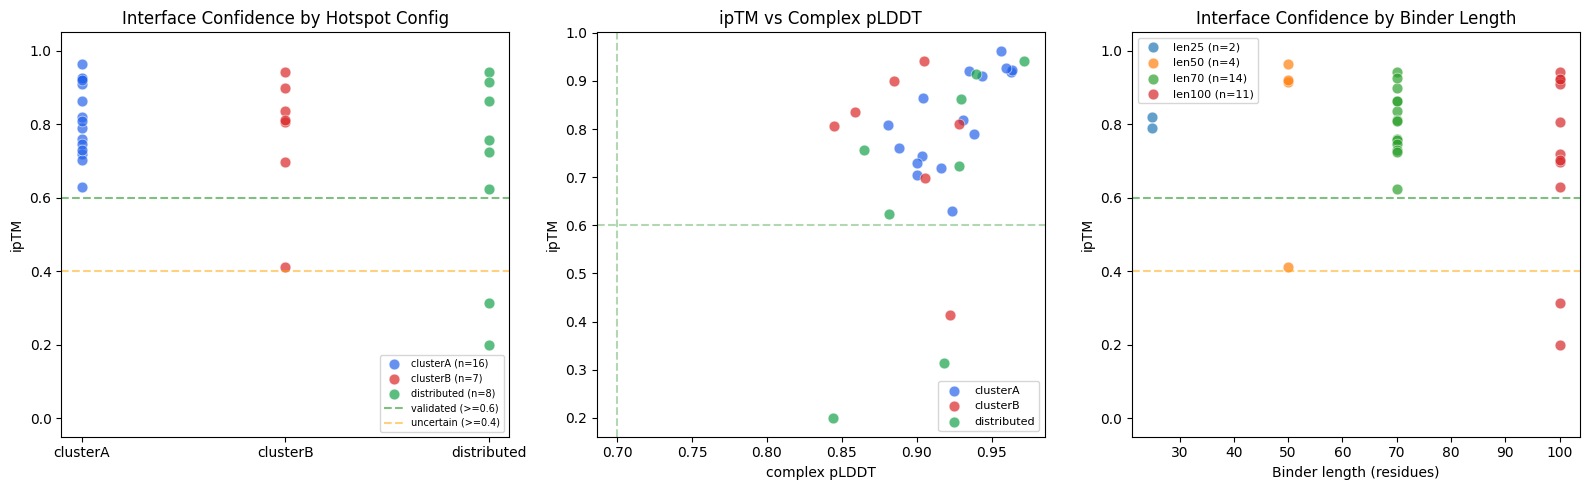

✓ Saved: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/boltz_complex_validation/boltz_confidence_overview.png


In [7]:
# ============================================================
# Cell 6 — Visualize Boltz-2 confidence metrics
# ============================================================
#
# Dependencies: Cell 5 (df_boltz with tiers)
# External files: None
# Compute: CPU only
# Purpose: Plot ipTM distribution, per-config comparison, tier breakdown
# Outputs: Plots saved to BOLTZ_DIR/
# ============================================================

import matplotlib.pyplot as plt

scored = df_boltz[df_boltz['boltz_status'] == 'success'].copy()

if len(scored) == 0:
    print("No scored designs — skipping visualization.")
else:
    colors = {
        'clusterA': '#2563eb',
        'clusterB': '#dc2626',
        'distributed': '#16a34a'
    }

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Panel 1: ipTM by hotspot config
    ax = axes[0]
    for config, color in colors.items():
        sub = scored[scored['hotspot_config'] == config]
        if len(sub) > 0:
            ax.scatter(
                [config] * len(sub), sub['ipTM'],
                color=color, s=60, alpha=0.7, edgecolors='white', linewidth=0.5,
                label=f"{config} (n={len(sub)})"
            )
    ax.axhline(IPTM_HIGH, color='green', linestyle='--', alpha=0.5, label=f'validated (>={IPTM_HIGH})')
    ax.axhline(IPTM_MID, color='orange', linestyle='--', alpha=0.5, label=f'uncertain (>={IPTM_MID})')
    ax.set_ylabel('ipTM')
    ax.set_title('Interface Confidence by Hotspot Config')
    ax.legend(fontsize=7, loc='lower right')
    ax.set_ylim(-0.05, 1.05)

    # Panel 2: ipTM vs complex_pLDDT
    ax = axes[1]
    if 'complex_pLDDT' in scored.columns:
        for config, color in colors.items():
            sub = scored[scored['hotspot_config'] == config]
            if len(sub) > 0:
                ax.scatter(
                    sub['complex_pLDDT'], sub['ipTM'],
                    color=color, s=60, alpha=0.7, edgecolors='white', linewidth=0.5,
                    label=config
                )
        ax.axhline(IPTM_HIGH, color='green', linestyle='--', alpha=0.3)
        ax.axvline(PLDDT_HIGH, color='green', linestyle='--', alpha=0.3)
        ax.set_xlabel('complex pLDDT')
        ax.set_ylabel('ipTM')
        ax.set_title('ipTM vs Complex pLDDT')
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, 'complex_pLDDT\nnot available', ha='center', va='center', transform=ax.transAxes)

    # Panel 3: ipTM by binder length
    ax = axes[2]
    for length in sorted(scored['length'].unique()):
        sub = scored[scored['length'] == length]
        ax.scatter(
            [length] * len(sub), sub['ipTM'],
            s=60, alpha=0.7, edgecolors='white', linewidth=0.5,
            label=f"len{length} (n={len(sub)})"
        )
    ax.axhline(IPTM_HIGH, color='green', linestyle='--', alpha=0.5)
    ax.axhline(IPTM_MID, color='orange', linestyle='--', alpha=0.5)
    ax.set_xlabel('Binder length (residues)')
    ax.set_ylabel('ipTM')
    ax.set_title('Interface Confidence by Binder Length')
    ax.legend(fontsize=8)
    ax.set_ylim(-0.05, 1.05)

    plt.tight_layout()
    plt.savefig(BOLTZ_DIR / 'boltz_confidence_overview.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {BOLTZ_DIR / 'boltz_confidence_overview.png'}")


In [8]:
# ============================================================
# Cell 7 — Correlate Boltz metrics with NB07 fingerprinting features
# ============================================================
#
# Dependencies: Cell 5 (df_boltz); NB07 outputs on Drive
# External files:
#   - fingerprint_summary.json from NB07
#   - design_chain_report.csv from NB07
# Compute: CPU only
# Purpose: Test whether Boltz confidence agrees with fingerprinting metrics
# Outputs: Correlation table and plot
#
# Scientific question: Do designs with higher pre-relaxation BSA, more
# contacts, or better hotspot coverage also get higher ipTM from Boltz?
# Agreement = the metrics are capturing the same underlying interface quality.
# Disagreement = one of the methods may be seeing something the other misses.
# ============================================================

FINGERPRINT_DIR = STUDY_DIR.parent / "fingerprinting_param_sensitivity"
CHAIN_REPORT = FINGERPRINT_DIR / "design_chain_report.csv"

if CHAIN_REPORT.exists() and 'ipTM' in df_boltz.columns:
    df_fp = pd.read_csv(CHAIN_REPORT)

    # Build a joinable design name from fingerprinting data
    if 'design' in df_fp.columns:
        df_fp = df_fp.rename(columns={'design': 'design_name'})
    elif 'condition_id' in df_fp.columns and 'seq_id' in df_fp.columns:
        df_fp['design_name'] = df_fp['condition_id'] + '__' + df_fp['seq_id']

    # Merge
    merge_cols = ['design_name']
    fp_features = [c for c in ['n_contacts', 'mean_plddt', 'rmsd'] if c in df_fp.columns]
    df_merged = df_boltz.merge(
        df_fp[merge_cols + fp_features].drop_duplicates(),
        on='design_name', how='left', suffixes=('', '_fp')
    )

    # Compute correlations
    boltz_metrics = [c for c in ['ipTM', 'complex_pLDDT', 'pTM'] if c in df_merged.columns]
    fp_metrics = [c for c in fp_features if c in df_merged.columns]

    if boltz_metrics and fp_metrics:
        scored_merged = df_merged[df_merged['boltz_status'] == 'success'].copy()

        print("=== Correlation: Boltz metrics vs NB07 fingerprinting ===")
        print(f"Designs with both Boltz + fingerprinting data: {len(scored_merged)}\n")

        corr_rows = []
        for bm in boltz_metrics:
            for fm in fp_metrics:
                valid = scored_merged[[bm, fm]].dropna()
                if len(valid) >= 5:
                    from scipy.stats import spearmanr
                    rho, pval = spearmanr(valid[bm], valid[fm])
                    corr_rows.append({
                        'boltz_metric': bm,
                        'fingerprint_metric': fm,
                        'spearman_rho': round(rho, 3),
                        'p_value': round(pval, 4),
                        'n': len(valid)
                    })

        if corr_rows:
            df_corr = pd.DataFrame(corr_rows)
            print(df_corr.to_string(index=False))
            df_corr.to_csv(BOLTZ_DIR / '09_boltz_vs_fingerprinting.csv', index=False)
            print(f"\n✓ Saved: {BOLTZ_DIR / '09_boltz_vs_fingerprinting.csv'}")
        else:
            print("Not enough data points for correlation analysis.")
    else:
        print("Insufficient overlapping metrics for correlation.")
else:
    print("Fingerprinting chain report not found or no Boltz scores available.")
    print(f"Looked for: {CHAIN_REPORT}")
    print("Skipping correlation analysis — will be possible after both NB07 and NB09 are complete.")


=== Correlation: Boltz metrics vs NB07 fingerprinting ===
Designs with both Boltz + fingerprinting data: 31

Not enough data points for correlation analysis.


In [9]:
# ============================================================
# Cell 8 — Export structured summary for portfolio page
# ============================================================
#
# Dependencies: Cell 5 (df_boltz with tiers)
# External files: None
# Compute: CPU only
# Purpose: Create a structured JSON summarizing Boltz validation results
# Outputs: 09_boltz_summary.json
# ============================================================

scored = df_boltz[df_boltz['boltz_status'] == 'success'].copy()

summary = {
    'notebook': '09_boltz_complex_validation',
    'model': 'Boltz-2',
    'total_designs': len(df_boltz),
    'scored_designs': len(scored),
    'target': 'PD-L1 ectodomain (4ZQK chain A, 115 aa)',
    'tier_thresholds': {
        'validated': f'ipTM >= {IPTM_HIGH} and complex_pLDDT >= {PLDDT_HIGH}',
        'uncertain': f'ipTM >= {IPTM_MID} or complex_pLDDT >= {PLDDT_MID}',
        'failed': f'ipTM < {IPTM_MID} and complex_pLDDT < {PLDDT_MID}',
    },
    'tier_counts': df_boltz['boltz_tier'].value_counts().to_dict(),
}

if len(scored) > 0 and 'ipTM' in scored.columns:
    summary['ipTM_stats'] = {
        'mean': round(float(scored['ipTM'].mean()), 3),
        'std': round(float(scored['ipTM'].std()), 3),
        'min': round(float(scored['ipTM'].min()), 3),
        'max': round(float(scored['ipTM'].max()), 3),
    }

    summary['ipTM_by_hotspot_config'] = {
        config: {
            'mean': round(float(sub['ipTM'].mean()), 3),
            'n': len(sub)
        }
        for config, sub in scored.groupby('hotspot_config')
    }

    summary['ipTM_by_length'] = {
        str(length): {
            'mean': round(float(sub['ipTM'].mean()), 3),
            'n': len(sub)
        }
        for length, sub in scored.groupby('length')
    }

    # Top designs
    top_n = min(5, len(scored))
    top = scored.nlargest(top_n, 'ipTM')
    summary['top_designs'] = [
        {
            'design_name': r['design_name'],
            'ipTM': round(float(r['ipTM']), 3),
            'complex_pLDDT': round(float(r.get('complex_pLDDT', 0)), 3),
            'hotspot_config': r['hotspot_config'],
            'length': int(r['length']),
            'tier': r['boltz_tier'],
        }
        for _, r in top.iterrows()
    ]

summary_path = BOLTZ_DIR / '09_boltz_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print(f"\n✓ Saved: {summary_path}")


{
  "notebook": "09_boltz_complex_validation",
  "model": "Boltz-2",
  "total_designs": 31,
  "scored_designs": 31,
  "target": "PD-L1 ectodomain (4ZQK chain A, 115 aa)",
  "tier_thresholds": {
    "validated": "ipTM >= 0.6 and complex_pLDDT >= 0.7",
    "uncertain": "ipTM >= 0.4 or complex_pLDDT >= 0.5",
    "failed": "ipTM < 0.4 and complex_pLDDT < 0.5"
  },
  "tier_counts": {
    "validated": 28,
    "uncertain": 3
  },
  "ipTM_stats": {
    "mean": 0.77,
    "std": 0.182,
    "min": 0.199,
    "max": 0.963
  },
  "ipTM_by_hotspot_config": {
    "clusterA": {
      "mean": 0.821,
      "n": 16
    },
    "clusterB": {
      "mean": 0.772,
      "n": 7
    },
    "distributed": {
      "mean": 0.667,
      "n": 8
    }
  },
  "ipTM_by_length": {
    "25": {
      "mean": 0.805,
      "n": 2
    },
    "50": {
      "mean": 0.803,
      "n": 4
    },
    "70": {
      "mean": 0.806,
      "n": 14
    },
    "100": {
      "mean": 0.706,
      "n": 11
    }
  },
  "top_designs": [
    

In [10]:
# ============================================================
# Cell 9 — Final output summary
# ============================================================
#
# Dependencies: All previous cells
# Purpose: List all generated files and summarize key findings
# ============================================================

print("=== Notebook 09 complete ===")
print(f"Results saved to: {BOLTZ_DIR}")
print("\nGenerated files:")
for p in sorted(BOLTZ_DIR.glob('*')):
    if p.is_file():
        print(f"  {p.name}")

print(f"\n--- Key findings ---")
print(f"Designs analyzed: {len(df_boltz)}")

for tier in ['validated', 'uncertain', 'failed', 'unscored']:
    count = (df_boltz['boltz_tier'] == tier).sum()
    if count > 0:
        print(f"  {tier}: {count}")

if 'ipTM' in df_boltz.columns:
    scored = df_boltz[df_boltz['boltz_status'] == 'success']
    if len(scored) > 0:
        best = scored.loc[scored['ipTM'].idxmax()]
        print(f"\nBest design: {best['design_name']}")
        print(f"  ipTM: {best['ipTM']:.3f}")
        if 'complex_pLDDT' in best and pd.notna(best.get('complex_pLDDT')):
            print(f"  complex_pLDDT: {best['complex_pLDDT']:.3f}")
        print(f"  hotspot_config: {best['hotspot_config']}")
        print(f"  length: {best['length']}")

print(f"\n--- Interpretation ---")
print("Boltz-2 confidence scores are NOT experimental binding affinities.")
print("They indicate whether an independent structure prediction model")
print("recovers a plausible binder-target interface from sequence alone.")
print("\nDesigns classified as 'validated' are recommended for prioritization")
print("in Notebook 10 (affinity scoring and construct selection).")
print("Designs classified as 'failed' should be deprioritized unless there")
print("is a specific reason to investigate further.")


=== Notebook 09 complete ===
Results saved to: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/boltz_complex_validation

Generated files:
  09_boltz_confidence_metrics.csv
  09_boltz_summary.json
  09_boltz_tier_classification.csv
  09_prediction_log.csv
  boltz_confidence_overview.png

--- Key findings ---
Designs analyzed: 31
  validated: 28
  uncertain: 3

Best design: len50_clusterA_noise05__design_0_0_rank0
  ipTM: 0.963
  complex_pLDDT: 0.956
  hotspot_config: clusterA
  length: 50

--- Interpretation ---
Boltz-2 confidence scores are NOT experimental binding affinities.
They indicate whether an independent structure prediction model
recovers a plausible binder-target interface from sequence alone.

Designs classified as 'validated' are recommended for prioritization
in Notebook 10 (affinity scoring and construct selection).
Designs classified as 'failed' should be deprioritized unless there
is a specific reason to investigate further.


In [6]:
"""
Aggregate Boltz-2 predicted CIF files into a single folder for GitHub Pages.

Run in Colab after mounting Google Drive.

Produces:
    /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/
        portfolio_pages/Page5_boltz/cif/{design_name}_model_0.cif
"""

import shutil
from pathlib import Path

# Mount Drive first in a separate cell:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/Othercomputers/My Mac/pdl1-mini-binder-design")

SOURCE_DIR = PROJECT_DIR / "data/results/boltz_complex_validation/outputs"
DEST_DIR = PROJECT_DIR / "portfolio_pages/Page5_boltz/cif"


def main():
    print(f"PROJECT_DIR: {PROJECT_DIR}")
    print(f"SOURCE_DIR:  {SOURCE_DIR}")
    print(f"DEST_DIR:    {DEST_DIR}")

    if not PROJECT_DIR.exists():
        raise FileNotFoundError(f"PROJECT_DIR does not exist:\n{PROJECT_DIR}")

    if not SOURCE_DIR.exists():
        raise FileNotFoundError(f"SOURCE_DIR does not exist:\n{SOURCE_DIR}")

    DEST_DIR.mkdir(parents=True, exist_ok=True)

    cif_files = sorted(
        SOURCE_DIR.glob("boltz_results_*/predictions/*/*_model_0.cif")
    )

    if not cif_files:
        cif_files = sorted(SOURCE_DIR.rglob("*_model_0.cif"))

    if not cif_files:
        print(f"\nNo CIF files found under:\n{SOURCE_DIR}")
        print("\nFirst files/folders found there:")
        for p in sorted(SOURCE_DIR.rglob("*"))[:80]:
            print(f"  {p.relative_to(SOURCE_DIR)}")
        return

    print(f"\nFound {len(cif_files)} CIF files")

    copied = 0

    for cif in cif_files:
        fname = cif.name

        if fname.startswith("confidence_"):
            fname = fname[len("confidence_"):]

        dest = DEST_DIR / fname
        shutil.copy2(cif, dest)

        copied += 1
        print(f"  copied: {fname}")

    print(f"\n✓ Copied {copied} CIF files")
    print(f"Destination:\n{DEST_DIR}")


if __name__ == "__main__":
    main()

Mounted at /content/drive
PROJECT_DIR: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design
SOURCE_DIR:  /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/boltz_complex_validation/outputs
DEST_DIR:    /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/portfolio_pages/Page5_boltz/cif

Found 31 CIF files
  copied: len100_clusterA_noise05__design_14_0_rank3_model_0.cif
  copied: len100_clusterA_noise05__design_3_0_rank2_model_0.cif
  copied: len100_clusterA_noise0__design_10_0_rank3_model_0.cif
  copied: len100_clusterA_noise0__design_13_0_rank4_model_0.cif
  copied: len100_clusterA_noise0__design_16_0_rank6_model_0.cif
  copied: len100_clusterA_noise0__design_9_0_rank8_model_0.cif
  copied: len100_clusterB_noise05__design_0_0_rank1_model_0.cif
  copied: len100_clusterB_noise05__design_13_0_rank0_model_0.cif
  copied: len100_distributed_noise0__design_15_0_rank5_model_0.cif
  copied: len100_distributed_noise0__design_18_0_rank1_model_0.cif
  copie